In [414]:
#import all the things we will need!
import numpy as np
import scipy.optimize as opt
import serial
import serial.tools.list_ports as ports
import time
import can
import struct
import matplotlib.pyplot as plt
import random #for testing (obviously)


# ----- Basic Motor Commands -----
def moveTo_XY(x, y):
    """
        Commands X-Y stage to move to specified point in x-y plane
        Inputs:
            x: float: X location to move to in mm (0-550)
            y: float: Y location to move to in mm (0-550)
    """
    if np.allclose(x, readPosition(3)) and np.allclose(y, readPosition(4)): # if were already there dont do anything
        return
         
    #Calculating steps based on distance and physical properties of rails
    steps_X = int(np.abs(x*stepsPerRotation_XY/mmPerThread))
    steps_Y = int(np.abs(y*stepsPerRotation_XY/mmPerThread))

    #match move times   
    if (np.abs(x-readPosition(3))*(np.abs(y-readPosition(4))) != 0): # if both axes are going to move
        speed_X = (np.min(np.array([maxVel_X, maxVel_Y*(np.abs(x-readPosition(3))/np.abs(y-readPosition(4)))]))) # some fancy math so that the axes move all nice (accelerate and move at the same time)
        speed_Y = (np.min(np.array([maxVel_Y, maxVel_X*(np.abs(y-readPosition(4))/np.abs(x-readPosition(3)))])))
        acc_X = (np.min(np.array([maxAcc_X, maxAcc_Y*speed_X/speed_Y])))
        acc_Y = (np.min(np.array([maxAcc_Y, maxAcc_X*speed_Y/speed_X])))
        setSpeedAcc(3, int(speed_X), int(acc_X)) #set the speeds and accelerations
        setSpeedAcc(4, int(speed_Y), int(acc_Y))
    elif (np.abs(x-readPosition(3)) == 0):
        setSpeedAcc(4, maxVel_Y, maxAcc_Y)
    elif (np.abs(y-readPosition(4)) == 0):
        setSpeedAcc(3, maxVel_X, maxAcc_X)

    # GO GO GO! (initiation)
    moveString_X = f"/3A{str(steps_X)}<CR>\r\n"
    moveString_Y = f"/4A{str(steps_Y)}<CR>\r\n"
    runString = f"/CR\r\n"
    
    #Command Motors GO GO GO!
    ser.write(moveString_X.encode('ascii'))
    time.sleep(0.05)
    ser.write(moveString_Y.encode('ascii'))
    time.sleep(0.05)
    ser.write(runString.encode('ascii'))
    time.sleep(0.05)
    print(f"XY command sent. Moving to ({x}, {y})") # we did it!


def moveRelative_XY(x, y):
    """
        Commands X-Y stage to move to specified point in x-y plane relative to its current position
        Inputs:
            x: float: X distance to move to in mm 
            y: float: Y distance to move to in mm 
    """
    if x == 0 and y == 0: # if were not gonna actually do something stop right now
        return
        
    #Calculating steps based on distance and physical properties of rails
    steps_X = int(abs(x*stepsPerRotation_XY/mmPerThread))
    steps_Y = int(abs(y*stepsPerRotation_XY/mmPerThread))

    #match move times
    if x*y !=0:
        speed_X = int(np.min(np.array([maxVel_X, maxVel_Y*(np.abs(x)/np.abs(y))]))) # some fancy math so that the axes move all nice (accelerate and move at the same time)
        speed_Y = int(np.min(np.array([maxVel_Y, maxVel_X*(np.abs(y)/np.abs(x))])))
        acc_X = int(np.min(np.array([maxAcc_X, maxAcc_Y*speed_X/speed_Y])))
        acc_Y = int(np.min(np.array([maxAcc_Y, maxAcc_X*speed_Y/speed_X])))
        setSpeedAcc(3, speed_X, acc_X) #set the speeds and accelerations
        setSpeedAcc(4, speed_Y, acc_Y)
    elif (x == 0):
        setSpeedAcc(4, maxVel_Y, maxAcc_Y)
    elif (y == 0):
        setSpeedAcc(3, maxVel_X, maxAcc_X)
        
    #Create String to send
    if x>0:
        moveString_X = f"/3P{str(steps_X)}<CR>\r\n"
    elif x<0:
        moveString_X = f"/3D{str(steps_X)}<CR>\r\n"
    else:
        moveString_X = f"/3P1<CR>\r\n" #Find a way to fix this ideally. when the realtive position is set to zero weird things happen, so i just make it 1 artifiacially so it barely moves
    if y>0:
        moveString_Y = f"/4P{str(steps_Y)}<CR>\r\n"
    elif y<0:
        moveString_Y = f"/4D{str(steps_Y)}<CR>\r\n"
    else:
        moveString_Y = f"/4P1<CR>\r\n"
    runString = f"/CR\r\n"

    #Command Motors
    ser.write(moveString_X.encode('ascii'))
    time.sleep(0.1)
    ser.write(moveString_Y.encode('ascii'))
    time.sleep(0.1)
    print(f"XY command sent. Moving by ({x}, {y}) to ({x + readPosition(3)}, {y + readPosition(4)})")
    ser.write(runString.encode('ascii'))
    time.sleep(0.1)

def moveTo_Ze(theta):
    """
        Commands zenith motor to move to specified point 
        Inputs:
            theta: float: location to move to (degrees)
    """
    steps_Ze = int(200*16*theta/360) #steps*microsteps*angle in degrees
    
    moveTo_CAN(7, steps_Ze)
    time.sleep(0.05)
    setSpeedAcc(7, maxVel_Ze, maxAcc_Ze)
    time.sleep(0.05)
    begin_CAN(7)
    
    print(f"Ze command sent. Moving zenith axis to {round(theta, 3)} degrees")


def moveRelative_Ze(theta):
    """
        Commands Zenith motor to move a certain amount from its current position
        Inputs:
            theta: float: distance to move in degrees
    """
    if theta == 0:
        return
    
    steps_Ze = int(200*16*theta/360) #steps*microsteps*angle in degrees
    
    moveRelative_CAN(7, steps_Ze)
    time.sleep(0.05)
    setSpeedAcc(7, maxVel_Ze, maxAcc_Ze)
    time.sleep(0.05)
    begin_CAN(7)
    print(f"Ze command sent. Moving zenith axis by {round(theta, 3)} degrees")

def moveTo_Az(theta):
    """
        Commands azimuth motor to move to specified point 
        Inputs:
            theta: float: location to move to (degrees)
    """
    steps_Az = int(6*200*16*theta/360) #gear ratio*steps*microsteps*angle in degrees

    moveTo_CAN(6, steps_Az)
    time.sleep(0.05)
    setSpeedAcc(6, maxVel_Az, maxAcc_Az)
    time.sleep(0.05)
    begin_CAN(6)
    
    print(f"Az command sent. Moving azimuth axis to {round(theta, 3)} degrees")


def moveRelative_Az(theta):
    """
        Commands azimuth motor to move a certain amount from its current position
        Inputs:
            theta: float: distance to move in degrees
    """
    if theta == 0:
        return
    
    steps_Az = int(6*200*16*theta/360) #gear ratio*steps*microsteps*angle in degrees
    
    moveRelative_CAN(6, steps_Az)
    time.sleep(0.05)
    setSpeedAcc(6, maxVel_Az, maxAcc_Az)
    time.sleep(0.05)
    begin_CAN(6)
    print(f"Az command sent. Moving azimuth axis by {round(theta, 3)} degrees")


def zero(motor):
    """
        Sets specified motor(s) be at zero at its current position
        Inputs:
          "_": all
          "C": Motors 3 and 4 (x-y stage)
            3: X
            4: Y
            5: chop
            6: az
            7: ze
    """
    if motor == 6 or motor == 7:
        zero_CAN(motor)
        return
        
    reset = f"/{motor}z0R\r\n"
    ser.write(reset.encode('ascii'))
    print(f"Motor {motor} has been zeroed")



def highZero(motor):
    """
        Sets specified motor(s) to be at a large number position for purposes of setting the zero value
        Inputs:
          "_": all
          "C": Motors 3 and 4 (x-y stage)
            3: X
            4: Y
            5: chop
            6: az
            7: ze
    """
    reset = f"/{motor}z100000000R\r\n"
    ser.write(reset.encode('ascii'))
    print(f"Motor {motor} has been set high")
    
def startChop(Hz):
    """
        turns on the chopper motor to turn indefinetly at a specified frequency
        Inputs: 
            Hz: float: the frequency that the chopper will chop the hear source at (Hz)

        negetive input spins CW, positive spins CCW    
    """
    #set up chop
    initString_Chop = f"/5m{curr_Chop}V{str(np.abs(Hz*200*256//2))}L{maxAcc_Chop}R\r\n" #for velocity: Hz * full steps * microsteps * 1/2 (chopper wheel has 2 on/offs per rotation)
    ser.write(initString_Chop.encode("ascii"))
    time.sleep(0.5)
    if Hz > 0: # so we can choose which way we go
        go = f"/5P0<CR>\r\n"
    elif Hz < 0:
        go = f"/5D0<CR>\r\n"
    else:
        return
    runString = f"/5R\r\n"
    
    #Command Motors
    ser.write(go.encode('ascii'))
    time.sleep(0.5)
    ser.write(runString.encode('ascii'))
    time.sleep(0.5)
    print("Chop started")
    
def stopChop():
    """
        Stops chopper motor
    """
    runString = f"/5TR\r\n"
    ser.write(runString.encode('ascii'))
    print("Chop stopped")

def setSpeedAcc(motor, speed, acc):
    """
        Sets the speed and acceleration for any given motor in the system
        Inputs:
            Motor: 
                "_": all
                "C": Motors 3 and 4 (x-y stage)
                  3: X
                  4: Y
                  5: chop
                  6: az
                  7: ze
            Speed: float: value to set motor speed to in steps/sec
            Acc: float: value to set motor acceleration to in steps/sec^2
    """
    if motor == 6 or motor == 7:
        setSpeed_CAN(motor, speed)
        time.sleep(0.1)
        setAcc_CAN(motor, acc)
        time.sleep(0.1)
        return
        
    initString = f"/{int(motor)}V{speed}L{acc}R\r\n"
    ser.write(initString.encode("ascii"))
    time.sleep(0.1)    

def readPosition(motor, timeout = 0.1):
    """
       gets the current position of any motor
       Inputs:
           motor: int: Motor for which the position is read
               3: X
               4: Y
               5: chop
               6: az
               7: ze
            timeout: float: time to wait in seconds before giving up on position read
        Outputs:
            Position: int: 
               ze in degrees
               az in degrees
               X in mm
               Y in mm
               chop in number of rotations
                
    """
    if (motor == 6):
        return (readPosition_CAN(6)/(6*200*16)*360)
    if (motor == 7):
        return (readPosition_CAN(7)/(200*16)*360)
        
        
    # Flush any leftover data in the buffers (AI came up with this one)
    ser.reset_input_buffer()
    ser.reset_output_buffer()

    command = f"/{motor}?0R\r\n"
    ser.write(command.encode('ascii'))

    time.sleep(0.05)
    response = ser.readline().decode('ascii', errors='ignore').strip()
    
    if motor == 3 or motor == 4:     
        return int(response[3:-1])/(stepsPerRotation_XY/mmPerThread)
    elif motor == 5:
        return int(response[3:-1])/(200*256)
    

def endAll():
    """
        Stops all motors
    """
    stopMotion_CAN(6)
    time.sleep(0.1)
    stopMotion_CAN(7)
    time.sleep(0.1)
    runString = f"/_TR\r\n"
    ser.write(runString.encode('ascii'))
    time.sleep(0.1)
    print("Current commands halted")

def close():
    """
        Closes serial port when done with beam mapper
    """
    ser.close()
    print(f"Port Closed")


# ----- CAN COMMAND SET -----
CAN_MO = 0x95   # Driver State (on/off)
CAN_SP = 0x9E   # PTP motor speed
CAN_PA = 0xA0   # Absolute position
CAN_PR = 0x9F   # Relative position
CAN_BG = 0x96   # Begin Motion
CAN_ZP = 0xA1   # Set position (zero)
CAN_IC = 0x86   # Internal Configuration
CAN_PA = 0xA0   # Absolute Position
CAN_AC = 0x90   # Acceleration
CAN_DC = 0x91   # Deceleration
CAN_ST = 0x97   # Stop motion
CAN_JV = 0x9D   # Jog velocity
CAN_SY = 0x7E   # System Operation

def motorOn_CAN(motor):
    """
        turns specified motor driver on
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """        
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_MO)),
        data=[0x01],
        is_extended_id=True
    ))
    time.sleep(0.05)

def motorOff_CAN(motor):
    """
        turns specified motor off
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_MO)),
        data=[0x00],
        is_extended_id=True
    ))

def enableClosedLoop_CAN(motor):
    """
        enables closed loop control of specified motor
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_IC)),
        data=[0x06, 0x01, 0x00],
        is_extended_id=True
    ))
    time.sleep(0.1)

def setAcc_CAN(motor, accel):
    """
        sets the acceleration of specified motor
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
            accel: int: acceleration of motor (pulse/sec^2)
    """        
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_AC)),
        data=struct.pack("<i", accel),
        is_extended_id=True
    ))

def setDecel_CAN(motor, decel):
    """
        sets the deceleration of specified motor
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
            decel: int: decceleration of motor (pulse/sec^2)
    """        
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_DC)),
        data=struct.pack("<i", decel),
        is_extended_id=True
    ))
    time.sleep(0.05)

def zero_CAN(motor):
    """
        sets the current specified motor position to be the zero position
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_ZP)),
        data=struct.pack("<i", 0),
        is_extended_id=True
    ))

def moveTo_CAN(motor, position):
    """
        commanads specified motor to move to a specific position
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
            position: int: position to move to (steps) (3200 in one rotation)
    """
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_PA)),
        data=struct.pack("<i", int(position)),
        is_extended_id=True
    ))
    
def moveRelative_CAN(motor, position):
    """
        commanads specified motor to move a certain amount
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
            position: int: amount to move by (steps) (3200 in one rotation)
    """
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_PR)),
        data=struct.pack("<i", int(position)),
        is_extended_id=True
    ))
    
def setSpeed_CAN(motor, speed):
    """
        sets the speed of specified motor
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
            speed: int: speed of motor (pulse/sec)
    """
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_SP)),
        data=struct.pack("<i", int(speed)),
        is_extended_id=True
    ))
    
def begin_CAN(motor):
    """
        activates newly set parameters and initiates motion. must be ran for motor to move
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_BG)),
        data=[],
        is_extended_id=True
    ))


def stopMotion_CAN(motor):
    """
        stops current motor movement
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_ST)),
        data=[],
        is_extended_id=True
    ))

def clearJogMode_CAN(motor):
    """
        sets jog velocity to zero. Used to enter PTP mode if stuck
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """
    # JV = 0 → exit jog / velocity mode
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_JV)),
        data=struct.pack("<i", 0),
        is_extended_id=True
    ))


def readPosition_CAN(motor, timeout=1.0):
    """
        Requests the current absolute encoder position of specified motor from the UIM342.
        Returns position (int) or None.
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """
    # some things I had to ask AI to come up with for me :(
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_PA)),
        data=[],
        is_extended_id=True
    ))

    t0 = time.time()
    while time.time() - t0 < timeout:
        msg = bus.recv(timeout=0.1)
        if msg is None:
            continue

        cw = msg.arbitration_id & 0xFF

        if cw == 0x20 and msg.dlc >= 4:
            pos = struct.unpack("<i", msg.data[:4])[0]
            return pos

    return None

def invertEncoderDirection_CAN(motor):
    """
        Inverts the encoder direction of specified motor. USE WITH CAUTION!!!
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """
    # IC[5] = 1 → invert encoder polarity
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_IC)),
        data=[0x05, 0x01, 0x00],
        is_extended_id=True
    ))

def restoreFactoryDefaults_CAN(motor):
    """
        sets specified motor back to factory settings
        Inputs:
            motor: int: number of motor to command
                6: az
                7: ze
    """        
    bus.send(can.Message(
        arbitration_id=(int(0x04000000 + motor*0x00080000+CAN_SY)),
        data=[0x02],
        is_extended_id=True
    ))

def changeMotorID():
    """
        Changes the ID number that the currently connetce dmotor is addressed with
        Input:
            ID: int: new ID of the motor (change manually in last entry of data array)
    """
    bus.send(can.Message(
        arbitration_id=0x04000081,
        data=[0x07, 0x07],
        is_extended_id=True
     ))

def PTMotion(startPos, endPos, XSpeed, YSpeed, XAcc, YAcc, travelPoints = 20):
    """
        Creates the motion parameters for interpolated motion
        Inputs: 
            startPos: tuple: in the form (x, y) (mm)
            endPos: tuple: in the form (x, y) (mm)
            XSpeed: float: speed in X direction (microsteps/sec)
            YSpeed: float: speed in Y direction (microsteps/sec)
            XAcc: float: acceleration in X direction (microsteps/sec^2)/(400,000,000/65536)
            YAcc: float: acceleration in Y direction (microsteps/sec^2)/(400,000,000/65536)
            travelPoints: int: number of points to interpolate  

        THIS FUNCTION ASSUMES THAT X AND Y SPEEDS AND ACCELERATIONS ARE SUCH THAT THEY ARIVE AT THEIR FINAL POSITION AT THE SAME TIME.
        ONLY INDENDED FOR USE IN THE "moveToAll_XY_smooth" FUNCTION
    """
    
    XDist = abs(startPos[0] - endPos[0])
    YDist = abs(startPos[1] - endPos[1])
    XSteps = int(np.abs(XDist*stepsPerRotation_XY/mmPerThread)) # conversion to steps
    YSteps = int(np.abs(YDist*stepsPerRotation_XY/mmPerThread))
    XAcc *= 400000000/65536 # conversion to steps/sec^2
    YAcc *= 400000000/65536
    XdirPos = np.sign(endPos[0] - startPos[0])
    YdirPos = np.sign(endPos[1] - startPos[1])
    if (XSpeed >= (XSteps*XAcc)**0.5) and (YSpeed >= (YSteps*YAcc)**0.5): # lots and lots of math down here. basiccaly if this is true we dont accelerate to the full speed before decelerating
        if XAcc != 0: 
            travelTime = (2*(XSteps/XAcc)**0.5) 
        else:
            travelTime = (2*(YSteps/YAcc)**0.5) 
        #assert(np.allclose((2*(XSteps/XAcc)**0.5), (2*(YSteps/YAcc)**0.5)))
    elif (XSpeed <= (XSteps*XAcc)**0.5) and (YSpeed <= (YSteps*YAcc)**0.5):
        if XAcc != 0:
            travelTime =  ((XSteps-(((XSpeed)**2)/XAcc))/XSpeed)+2*XSpeed/XAcc
        else:
            travelTime =  ((YSteps-(((YSpeed)**2)/YAcc))/YSpeed)+2*YSpeed/YAcc
        #assert(np.allclose(((XSteps-(((XSpeed)**2)/XAcc))/XSpeed)+2*XSpeed/XAcc, ((YSteps-(((YSpeed)**2)/YAcc))/YSpeed)+2*YSpeed/YAcc))
    else:
        print("UHHH? yeah idk man") # somethings wrong if this happens
        
    pointCount = np.min(np.array([travelPoints, np.round(travelTime/0.005)])) ## min point spacing can be 5 ms so we need to do this
    
    def position(t):
        """
            a function that you can call to find where the X and Y axes are at a specific time
            Inputs:
                t: float: time at which you want to determine position
        """
        if XAcc*YAcc != 0:
            if XSpeed >= (XSteps*XAcc)**0.5: # this is for if we dont accelerate to full speed before deceleration
                if t>=0 and t<= travelTime/2:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*t**2)
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*t**2)
                elif t > travelTime/2 and t <= travelTime:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*(travelTime/2)**2 + XAcc*mmPerThread/stepsPerRotation_XY*(travelTime/2)*(t-travelTime/2)+0.5*-XAcc*mmPerThread/stepsPerRotation_XY*(t-travelTime/2)**2)
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*(travelTime/2)**2 + YAcc*mmPerThread/stepsPerRotation_XY*(travelTime/2)*(t-travelTime/2)+0.5*-YAcc*mmPerThread/stepsPerRotation_XY*(t-travelTime/2)**2)
                else:
                    print("Time request out of range")
                    return
            else: # this is for if we do accelerate to full speed before deceleration
                if t>=0 and t<= XSpeed/XAcc:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*t**2)
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*t**2)
                elif t > XSpeed/XAcc and t <= travelTime - XSpeed/XAcc:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)**2 + XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)*(t-XSpeed/XAcc))
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)**2 + YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)*(t-YSpeed/YAcc))
                elif t > travelTime - XSpeed/XAcc and t <= travelTime:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)**2 + XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)*(travelTime-2*XSpeed/XAcc) + XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)*(t-(travelTime-XSpeed/XAcc)) + 0.5*-XAcc*mmPerThread/stepsPerRotation_XY*(t-(travelTime-XSpeed/XAcc))**2)
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)**2 + YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)*(travelTime-2*YSpeed/YAcc) + YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)*(t-(travelTime-YSpeed/YAcc)) + 0.5*-YAcc*mmPerThread/stepsPerRotation_XY*(t-(travelTime-YSpeed/YAcc))**2)
                else:
                    print("Time request out of range")
                    return
        elif XAcc == 0:
            x = readPosition(3)
            if YSpeed >= (YSteps*YAcc)**0.5: # this is for if we dont accelerate to full speed before deceleration
                if t>=0 and t<= travelTime/2:
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*t**2)
                elif t > travelTime/2 and t <= travelTime:
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*(travelTime/2)**2 + YAcc*mmPerThread/stepsPerRotation_XY*(travelTime/2)*(t-travelTime/2)+0.5*-YAcc*mmPerThread/stepsPerRotation_XY*(t-travelTime/2)**2)
                else:
                    print("Time request out of range")
                    return
            else: # this is for if we do accelerate to full speed before deceleration
                if t>=0 and t<= YSpeed/YAcc:
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*t**2)
                elif t > YSpeed/YAcc and t <= travelTime - YSpeed/YAcc:
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)**2 + YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)*(t-YSpeed/YAcc))
                elif t > travelTime - YSpeed/YAcc and t <= travelTime:
                    y = readPosition(4) + YdirPos*(0.5*YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)**2 + YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)*(travelTime-2*YSpeed/YAcc) + YAcc*mmPerThread/stepsPerRotation_XY*(YSpeed/YAcc)*(t-(travelTime-YSpeed/YAcc)) + 0.5*-YAcc*mmPerThread/stepsPerRotation_XY*(t-(travelTime-YSpeed/YAcc))**2)
                else:
                    print("Time request out of range")
                    return
        elif YAcc == 0:
            y = readPosition(4)
            if XSpeed >= (XSteps*XAcc)**0.5: # this is for if we dont accelerate to full speed before deceleration
                y = readPosition(4)
                if t>=0 and t<= travelTime/2:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*t**2)
                elif t > travelTime/2 and t <= travelTime:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*(travelTime/2)**2 + XAcc*mmPerThread/stepsPerRotation_XY*(travelTime/2)*(t-travelTime/2)+0.5*-XAcc*mmPerThread/stepsPerRotation_XY*(t-travelTime/2)**2)
                else:
                    print("Time request out of range")
                    return
            else: # this is for if we do accelerate to full speed before deceleration
                if t>=0 and t<= XSpeed/XAcc:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*t**2)
                elif t > XSpeed/XAcc and t <= travelTime - XSpeed/XAcc:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)**2 + XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)*(t-XSpeed/XAcc))
                elif t > travelTime - XSpeed/XAcc and t <= travelTime:
                    x = readPosition(3) + XdirPos*(0.5*XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)**2 + XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)*(travelTime-2*XSpeed/XAcc) + XAcc*mmPerThread/stepsPerRotation_XY*(XSpeed/XAcc)*(t-(travelTime-XSpeed/XAcc)) + 0.5*-XAcc*mmPerThread/stepsPerRotation_XY*(t-(travelTime-XSpeed/XAcc))**2)
                else:
                    print("Time request out of range")
                    return
        return x, y
    position = np.vectorize(position) # not sure if we need this but im keeping it
    dt = np.round(travelTime/pointCount, 3) # so this will lead to some innacuracies since PT motion requres time spacing to be the same between points but it should be smalll enought to not matter (hopefully)
    t = np.arange(0, travelTime, dt)
    t = np.append(t, travelTime)
    vals = np.array([position(time) for time in t])
    x = vals[:, 0]
    y = vals[:, 1]

    thetaPoints = findTheta(x, y)
    phiPoints = findPhi(x, y)
    thetaPoints_steps = np.round(thetaPoints*200*16/(2*np.pi))
    phiPoints_steps = np.round(phiPoints*6*200*16/(2*np.pi))
    plt.plot(t, thetaPoints)
    plt.plot(t, phiPoints)
    
    
    bus.send(can.Message( #reset
        arbitration_id=0x040000A2,
        data=[0x00, 0x01],
        is_extended_id=True
    ))
    time.sleep(0.05)
    bus.send(can.Message( # first valid row
        arbitration_id=0x040000A2,
        data=[0x01, 0x01],
        is_extended_id=True
    ))
    
    time.sleep(0.05)
    bus.send(can.Message( # last valid row
        arbitration_id=0x040000A2,
        data=[0x02, int(len(t))],
        is_extended_id=True
    ))
    
    time.sleep(0.05)
    bus.send(can.Message(# Loop mode
        arbitration_id=0x040000A2,
        data=[0x03, 0x01],
        is_extended_id=True
    ))

    time.sleep(0.05)
    dtms = int(dt*1000)
    timeHex = dtms.to_bytes(4, 'little', signed=True)
    bus.send(can.Message( # time interval
        arbitration_id=0x040000A2,
        data=list(bytes([0x04]) + timeHex),
        is_extended_id=True
    ))
    
    time.sleep(0.05)
    bus.send(can.Message( # que low alert value
        arbitration_id=0x040000A2,
        data=[0x05, 0x00],
        is_extended_id=True
    ))

    def build_pt_data(line_number, qp): # AI did this (sorry yall)
        if not (0 <= line_number <= 0xFFFF):
            raise ValueError("line_number must be 0..65535")
        if not (-0x80000000 <= qp <= 0x7FFFFFFF):
            raise ValueError("qp must fit in signed 4 bytes")
        
        line_bytes = line_number.to_bytes(2, 'little', signed=False)
        qp_bytes = qp.to_bytes(4, 'little', signed=True)
        return list(line_bytes + qp_bytes + bytes([0x00, 0x00]))

    for i in range(len(t)):
        bus.send(can.Message(
            arbitration_id=0x043000A4,
            data=build_pt_data((i+1), int(phiPoints_steps[i])),
            is_extended_id=True
            ))
        time.sleep(0.05)
        bus.send(can.Message(
            arbitration_id=0x043800A4,
            data=build_pt_data((i+1), int(thetaPoints_steps[i])),
            is_extended_id=True
        ))
        time.sleep(0.05)
        
    bus.send(can.Message(
        arbitration_id=0x040000A3,
        data=[0x01],
        is_extended_id=True
        ))
    time.sleep(0.05)
    

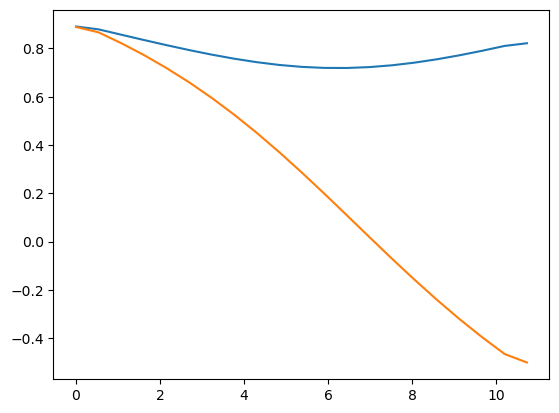

In [428]:

def moveToAll_XY_smooth(x, y):
    """
        Moves all motors so that the the heat source is pointed towards a target some distance (H defined below) above (x, y) = (275, 275)
        Inputs:
            x: float: X location to move to in mm (0-550)
            y: float: Y location to move to in mm (0-550)
    """
    if np.allclose(x, readPosition(3)) and np.allclose(y, readPosition(4)): # if were already there dont do anything
        return
    #Calculating steps based on distance and physical properties of rails---------------------------------------------
    steps_X = int(np.abs(x*stepsPerRotation_XY/mmPerThread))
    steps_Y = int(np.abs(y*stepsPerRotation_XY/mmPerThread))

    # matching Move times---------------------------------------------------------------------------------------------
    if not np.allclose (np.abs(x-readPosition(3))*(np.abs(y-readPosition(4))), 0):
        speed_X = (np.min(np.array([maxVel_X, maxVel_Y*(np.abs(x-readPosition(3))/np.abs(y-readPosition(4)))])))
        speed_Y = (np.min(np.array([maxVel_Y, maxVel_X*(np.abs(y-readPosition(4))/np.abs(x-readPosition(3)))])))
        acc_X = (np.min(np.array([maxAcc_X, maxAcc_Y*speed_X/speed_Y])))
        acc_Y = (np.min(np.array([maxAcc_Y, maxAcc_X*speed_Y/speed_X])))
        setSpeedAcc(3, int(speed_X), int(acc_X))
        setSpeedAcc(4, int(speed_Y), int(acc_Y))
    elif (np.abs(x-readPosition(3)) == 0):
        speed_X = 0
        speed_Y = maxVel_Y
        acc_X = 0
        acc_Y = maxAcc_Y
        setSpeedAcc(4, maxVel_Y, maxAcc_Y)
    elif (np.abs(y-readPosition(4)) == 0):
        speed_X = maxVel_X
        speed_Y = 0
        acc_X = maxAcc_X
        acc_Y = 0
        setSpeedAcc(3, maxVel_X, maxAcc_X)
        
    # #Create String to send-----------------------------------------------------------------------------------------
    moveString_X = f"/3A{str(steps_X)}<CR>\r\n"
    moveString_Y = f"/4A{str(steps_Y)}<CR>\r\n"
    runString = f"/CR\r\n"


    #Command Motors--------------------------------------------------------------------------------------------------
    ser.write(moveString_X.encode('ascii'))
    time.sleep(0.1)
    ser.write(moveString_Y.encode('ascii'))
    time.sleep(0.1)
    
    PTMotion((readPosition(3), readPosition(4)), (x, y), speed_X, speed_Y, acc_X, acc_Y)
    time.sleep(0.05)
    begin_CAN(0)
    time.sleep(0.5)
    ser.write(runString.encode('ascii'))
    time.sleep(0.1)
    

moveToAll_XY_smooth(100, 400)

In [420]:
moveToAll_XY(0, 451)

Ze command sent. Moving zenith axis to 58.51 degrees
Az command sent. Moving azimuth axis to -28.118 degrees


100.0

In [288]:
def moveToAll_XY_smooth_test(x, y, xOld, yOld):
    """
        Moves all motors so that the the heat source is pointed towards a target some distance (H defined below) above (x, y) = (275, 275)
        Inputs:
            x: float: X location to move to in mm (0-550)
            y: float: Y location to move to in mm (0-550)
    """
    #Calculating steps based on distance and physical properties of rails---------------------------------------------
    steps_X = int(np.abs((x-xOld)*stepsPerRotation_XY/mmPerThread))
    steps_Y = int(np.abs((y-yOld)*stepsPerRotation_XY/mmPerThread))

    # matching Move times---------------------------------------------------------------------------------------------
    if not np.allclose(np.abs(x-xOld)*(np.abs(y-yOld)), 0):
        speed_X = (np.min(np.array([maxVel_X, maxVel_Y*(np.abs(x-xOld)/np.abs(y-yOld))])))
        speed_Y = (np.min(np.array([maxVel_Y, maxVel_X*(np.abs(y-yOld)/np.abs(x-xOld))])))
        acc_X = (np.min(np.array([maxAcc_X, maxAcc_Y*speed_X/speed_Y])))
        acc_Y = (np.min(np.array([maxAcc_Y, maxAcc_X*speed_Y/speed_X])))
    elif (np.abs(x-xOld) == 0):
        setSpeedAcc(4, maxVel_Y, maxAcc_Y)
    elif (np.abs(y-yOld) == 0):
        setSpeedAcc(3, maxVel_X, maxAcc_X)
    print(steps_X)
    print(steps_Y)
    print(speed_X)
    print(speed_Y)
    print(acc_X)
    print(acc_Y)

moveToAll_XY_smooth_test(0, 0, 550, 100)

5632000
1024000
90000.0
16363.636363636364
100.0
18.181818181818183


In [289]:
#### ----- Complex Motor Commands -----

def moveToAll_XY_smooth(x, y):
    """
        Moves all motors so that the the heat source is pointed towards a target some distance (H defined below) above (x, y) = (275, 275)
        Inputs:
            x: float: X location to move to in mm (0-550)
            y: float: Y location to move to in mm (0-550)
    """
    #Calculating steps based on distance and physical properties of rails---------------------------------------------
    steps_X = int(np.abs(x*stepsPerRotation_XY/mmPerThread))
    steps_Y = int(np.abs(y*stepsPerRotation_XY/mmPerThread))

    # matching Move times---------------------------------------------------------------------------------------------
    if not np.allclose (np.abs(x-readPosition(3))*(np.abs(y-readPosition(4))), 0):
        speed_X = (np.min(np.array([maxVel_X, maxVel_Y*(np.abs(x-readPosition(3))/np.abs(y-readPosition(4)))])))
        speed_Y = (np.min(np.array([maxVel_Y, maxVel_X*(np.abs(y-readPosition(4))/np.abs(x-readPosition(3)))])))
        acc_X = (np.min(np.array([maxAcc_X, maxAcc_Y*speed_X/speed_Y])))
        acc_Y = (np.min(np.array([maxAcc_Y, maxAcc_X*speed_Y/speed_X])))
        setSpeedAcc(3, int(speed_X), int(acc_X))
        setSpeedAcc(4, int(speed_Y), int(acc_Y))
    elif (np.abs(x-readPosition(3)) == 0):
        setSpeedAcc(4, maxVel_Y, maxAcc_Y)
    elif (np.abs(y-readPosition(4)) == 0):
        setSpeedAcc(3, maxVel_X, maxAcc_X)
        
    # #Create String to send-----------------------------------------------------------------------------------------
    moveString_X = f"/3A{str(steps_X)}<CR>\r\n"
    moveString_Y = f"/4A{str(steps_Y)}<CR>\r\n"
    runString = f"/CR\r\n"


    #Command Motors--------------------------------------------------------------------------------------------------
    ser.write(moveString_X.encode('ascii'))
    time.sleep(0.1)
    ser.write(moveString_Y.encode('ascii'))
    time.sleep(0.1)
    ser.write(runString.encode('ascii'))
    time.sleep(0.1)
    
    while not (np.allclose(x,readPosition(3)) and np.allclose(y, readPosition(4))): # this whole thing makes it so we dont do a full 360 when trying to move to a point across a seam
        phiTarget = int(6*200*16*findPhi(readPosition(3), readPosition(4))/(2*np.pi))
        rotSame = ((readPosition_CAN(6)//(6*200*16))*6*200*16+phiTarget)
        rotPlus = ((readPosition_CAN(6)//(6*200*16)+1)*6*200*16+phiTarget)
        rotMinus = ((readPosition_CAN(6)//(6*200*16)-1)*6*200*16+phiTarget)
        currPos = readPosition_CAN(6)
        findMin = np.min(np.array([(abs(currPos - rotSame)), (abs(currPos - rotPlus)), (abs(currPos - rotMinus))]))
        if findMin == (abs(currPos - rotSame)):
            moveTo_CAN(6, rotSame)
        elif findMin == (abs(currPos - rotPlus)):
            moveTo_CAN(6, rotPlus)   
        else:
            moveTo_CAN(6, rotMinus)
        time.sleep(0.1)
        moveTo_CAN(7, int(200*16*findTheta(readPosition(3), readPosition(4))/(2*np.pi)))
        time.sleep(0.1)
        begin_CAN(0)

    phiTarget = int(6*200*16*findPhi(readPosition(3), readPosition(4))/(2*np.pi))
    rotSame = ((readPosition_CAN(6)//(6*200*16))*6*200*16+phiTarget)
    rotPlus = ((readPosition_CAN(6)//(6*200*16)+1)*6*200*16+phiTarget)
    rotMinus = ((readPosition_CAN(6)//(6*200*16)-1)*6*200*16+phiTarget)
    currPos = readPosition_CAN(6)
    findMin = np.min(np.array([(abs(currPos - rotSame)), (abs(currPos - rotPlus)), (abs(currPos - rotMinus))]))
    if findMin == (abs(currPos - rotSame)):
        moveTo_CAN(6, rotSame)
    elif findMin == (abs(currPos - rotPlus)):
        moveTo_CAN(6, rotPlus)   
    else:
        moveTo_CAN(6, rotMinus)
    time.sleep(0.1)
    moveTo_CAN(7, int(200*16*findTheta(readPosition(3), readPosition(4))/(2*np.pi)))
    time.sleep(0.1)
    begin_CAN(0)

    
def moveToAll_XY(x, y):
    """
        Moves all motors so that the the heat source is pointed towards a target some distance (H defined below) above (x, y) = (275, 275)
        Inputs:
            x: float: X location to move to in mm (0-550)
            y: float: Y location to move to in mm (0-550)
    """
    #Calculating steps based on distance and physical properties of rails---------------------------------------------
    steps_X = int(np.abs(x*stepsPerRotation_XY/mmPerThread))
    steps_Y = int(np.abs(y*stepsPerRotation_XY/mmPerThread))

    # matching Move times---------------------------------------------------------------------------------------------
    if not np.allclose (np.abs(x-readPosition(3))*(np.abs(y-readPosition(4))), 0):
        speed_X = (np.min(np.array([maxVel_X, maxVel_Y*(np.abs(x-readPosition(3))/np.abs(y-readPosition(4)))])))
        speed_Y = (np.min(np.array([maxVel_Y, maxVel_X*(np.abs(y-readPosition(4))/np.abs(x-readPosition(3)))])))
        acc_X = (np.min(np.array([maxAcc_X, maxAcc_Y*speed_X/speed_Y])))
        acc_Y = (np.min(np.array([maxAcc_Y, maxAcc_X*speed_Y/speed_X])))
        setSpeedAcc(3, int(speed_X), int(acc_X))
        setSpeedAcc(4, int(speed_Y), int(acc_Y))
    elif (np.abs(x-readPosition(3)) == 0):
        setSpeedAcc(4, maxVel_Y, maxAcc_Y)
    elif (np.abs(y-readPosition(4)) == 0):
        setSpeedAcc(3, maxVel_X, maxAcc_X)
        
    # #Create String to send-----------------------------------------------------------------------------------------
    moveString_X = f"/3A{str(steps_X)}<CR>\r\n"
    moveString_Y = f"/4A{str(steps_Y)}<CR>\r\n"
    runString = f"/CR\r\n"


    #Command Motors--------------------------------------------------------------------------------------------------
    ser.write(moveString_X.encode('ascii'))
    time.sleep(0.1)
    ser.write(moveString_Y.encode('ascii'))
    time.sleep(0.1)
    ser.write(runString.encode('ascii'))
    time.sleep(0.1)

    setSpeedAcc(2, int(maxVel_Az), int(maxAcc_Az))
    setSpeedAcc(1, int(maxVel_Ze), int(maxAcc_Ze))

    moveTo_Ze(findTheta(x, y)*180/np.pi)
    time.sleep(0.05)
    moveTo_Az(findPhi(x, y)*180/np.pi)

def moveToAll_thetaPhi(theta, phi):
    """
        Moves all motors so that the the heat source is pointed towards a target some distance (H defined below) above (x, y) = (275, 275)
        Inputs:
            theta: float: theta position to move to (degrees)
            phi: float: phi position to move to (degrees)
    """
    x, y = findXY(theta*np.pi/180, phi*np.pi/180)
    if (np.abs(x - d/2) > d/2) or (np.abs(y - d/2) > d/2):
        print(f"Out of bounds request error. ({x}, {y})")
        return
    #Calculating steps based on distance and physical properties of rails---------------------------------------------
    steps_X = int(np.abs(x*stepsPerRotation_XY/mmPerThread))
    steps_Y = int(np.abs(y*stepsPerRotation_XY/mmPerThread))

    # matching Move times---------------------------------------------------------------------------------------------
    if (not np.allclose(np.abs(x-readPosition(3))*(np.abs(y-readPosition(4))), 0)):
        speed_X = (np.min(np.array([maxVel_X, maxVel_Y*(np.abs(x-readPosition(3))/np.abs(y-readPosition(4)))])))
        speed_Y = (np.min(np.array([maxVel_Y, maxVel_X*(np.abs(y-readPosition(4))/np.abs(x-readPosition(3)))])))
        acc_X = (np.min(np.array([maxAcc_X, maxAcc_Y*speed_X/speed_Y])))
        acc_Y = (np.min(np.array([maxAcc_Y, maxAcc_X*speed_Y/speed_X])))
        setSpeedAcc(3, int(speed_X), int(acc_X))
        setSpeedAcc(4, int(speed_Y), int(acc_Y))
    elif (np.abs(x-readPosition(3)) == 0):
        setSpeedAcc(4, maxVel_Y, maxAcc_Y)
    elif (np.abs(y-readPosition(4)) == 0):
        setSpeedAcc(3, maxVel_X, maxAcc_X)
        
    # #Create String to send-----------------------------------------------------------------------------------------
    moveString_X = f"/3A{str(steps_X)}<CR>\r\n"
    moveString_Y = f"/4A{str(steps_Y)}<CR>\r\n"
    runString = f"/CR\r\n"


    #Command Motors--------------------------------------------------------------------------------------------------
    ser.write(moveString_X.encode('ascii'))
    time.sleep(0.1)
    ser.write(moveString_Y.encode('ascii'))
    time.sleep(0.1)
    ser.write(runString.encode('ascii'))
    time.sleep(0.1)
    
    moveTo_Ze(theta)
    time.sleep(0.1)
    moveTo_Az(phi)



In [163]:
moveToAll_XY_smooth(550, 100)

In [381]:
port_CAN = 'COM5' # Change according to your computer. Look in Device Manager
port_RS485 = 'COM3' # Change according to your computer. Look in Device Manager

baud = 9600 # for RS485
BITRATE = 500000 #for CAN

#Initialization for RS485 Port
ser = serial.Serial(port_RS485, baudrate = baud, timeout = 1)
time.sleep(0.5)
ser.reset_input_buffer()
ser.reset_output_buffer()

#initiates CAN bus port
bus = can.interface.Bus(
    interface="slcan",
    channel=port_CAN,
    bitrate=BITRATE
    )
motorOn_CAN(0)
print("Ports active")

slcanBus was not properly shut down
Exception ignored in: <function BusABC.__del__ at 0x0000026BD45FD940>
Traceback (most recent call last):
  File "C:\Users\oweni\anaconda3\Lib\site-packages\can\bus.py", line 499, in __del__
    self.shutdown()
  File "C:\Users\oweni\anaconda3\Lib\site-packages\can\interfaces\slcan.py", line 370, in shutdown
    self.close()
  File "C:\Users\oweni\anaconda3\Lib\site-packages\can\interfaces\slcan.py", line 251, in close
    self._write("C")
  File "C:\Users\oweni\anaconda3\Lib\site-packages\can\interfaces\slcan.py", line 210, in _write
    with error_check("Could not write to serial device"):
  File "C:\Users\oweni\anaconda3\Lib\contextlib.py", line 162, in __exit__
    self.gen.throw(value)
  File "C:\Users\oweni\anaconda3\Lib\site-packages\can\exceptions.py", line 121, in error_check
    raise exception_type(error_message) from error
can.exceptions.CanOperationError: Could not write to serial device


Ports active


In [297]:
#Motor Numbers:
#   Zenith: 1 (6*200*16 for one full rotation of az-ze stage)
#   Azimuth: 2
#   X: 3
#   Y: 4
#   Chop: 5

stepsPerRotation_XY = 200*256 #full steps * number of microsteps
mmPerThread = 5 # 5 was roughly measured (dont ask Owen about this)


maxVel_X = 90000 #Microsteps/Second (90000 MAX works for 256 microsteps) (int)
maxAcc_X = 100 #Microsteps/Second^2 / (400,000,000/65536) (int)
curr_X = 100 #Movement Current as a percentage of max (Typically Use 100) (int)

maxVel_Y = 300000 #Microsteps/Second (400000 MAX works for 256 microsteps) (int)
maxAcc_Y = 100 #Microsteps/Second^2 / (400,000,000/65536) (int)
curr_Y = 100 #Movement Current as a percentage of max (Typically Use 100) (int)

maxVel_Ze = 50000 #Microsteps/Second (50000 works for 256 microsteps) (int)
maxAcc_Ze = 100 #Microsteps/Second^2 / (400,000,000/65536)  (int)
curr_Ze = 100 #Movement Current as a percentage of max (Typically Use 100) (int)

maxVel_Az = 32000 #Microsteps/Second (32000 works fast and safe for 16 microsteps) (int)
maxAcc_Az = 100 #Microsteps/Second^2  (int) FIGURE THIS OUT
# curr_Az = 2 #current working current (not sure how this effects movement so leaving it at the deffault for now) (int)

curr_Chop = 100 #Movement Current as a percentage of max (Typically Use 100) (int)
maxAcc_Chop = 100 #Microsteps/Second^2 / (400,000,000/65536) (int)

# k = 10 #heat source height above zenith rotation axis (mm) (dont think we actually need)
g = 25.625 #distance of heat source from center of azimuth rotation axis in direction parllel to zenith rotation axis (pos. towards az Motor)(mm)
h = 200 #vertical distnace from center of zenith rotation axis to point where the heat source should be aimed at (mm)
j = 0 #distance of heat source from center of azimuth rotation axis in direction perpendicular to zenith rotation axis (pos. opposite dir. of chop motor set screw) (mm)

d = 550 #max x/y distance to travel. used so rail limit is not exceeded (mm)

In [298]:

initString_X = f"/3m{curr_X}V{maxVel_X}L{maxAcc_X}R\r\n"
initString_Y = f"/4m{curr_Y}V{maxVel_Y}L{maxAcc_Y}R\r\n"

#Initalization for RS485 Port
ser.write(initString_X.encode("ascii"))
time.sleep(0.1)
ser.write(initString_Y.encode("ascii"))
time.sleep(0.1)

setSpeedAcc(7, maxVel_Ze, maxAcc_Ze)
time.sleep(0.05)
setSpeedAcc(6, maxVel_Az, maxAcc_Az)
time.sleep(0.05)
setSpeedAcc(3, maxVel_X, maxAcc_X)
time.sleep(0.05)
setSpeedAcc(4, maxVel_Y, maxAcc_Y)
time.sleep(0.05)
setSpeedAcc(5, 0, maxAcc_Chop)
time.sleep(0.05)

print("Initiation Complete")

Initiation Complete


In [299]:
#math Functions

def findTheta(x, y):
    """
        determines the amount to angle the heat source given its postion
        Inputs:
            X_A: float: X position (mm)
            X_A: float: Y position (mm)
        Outputs:
            theta: float: Angle of heat source in radians
    """
    def thetaFunc(theta, x, y):
        return np.arctan2(((((x-275)**2)+(y-275)**2)**0.5+j/np.cos(theta)), (h))-theta

    return opt.brentq(thetaFunc, -np.pi, np.pi/2, args = (x, y))
findTheta = np.vectorize(findTheta)

def findPhi(x, y):
    """
        determines the amount rotate the az stage given xy position
        Inputs:
            X_A: float: X position (mm)
            X_A: float: Y position (mm)
        Outputs:
            phi: float: Angle of az stage in radians
    """
    def phiFunc(phi, x, y):
        return np.arctan2((-(y-275)+g*np.cos(phi)), (-(x-275)-g*np.sin(phi)))-phi
    
    return (opt.brentq(phiFunc, -np.pi, np.pi, args = (x, y)))
findPhi = np.vectorize(findPhi)

def findXY(theta, phi):
    x = -h*np.tan(theta)*np.cos(phi)+(j/np.cos(theta))*np.cos(phi)-g*np.sin(phi)+d/2
    y = -h*np.tan(theta)*np.sin(phi)+(j/np.cos(theta))*np.sin(phi)+g*np.cos(phi)+d/2 
    return np.array([x, y])
                     


In [7]:
print(findXY(0, 0))
print(findXY(0, 180*np.pi/180))

[275.    300.625]
[275.    249.375]


In [300]:
def moveToPoints_XY(points, measureTime):
    """
        commands XY stage to move to a set of speciffied points in the XY plane one after another
        Inputs:
            points: nx2 array of x-y points to move to in mm
            measureTime: float: time waited at each point for taking measurments (s)
    """
    numPoints = len(points)

    for point in range(numPoints):
        moveToAll_XY(points[point][0], points[point][1])
        while not (np.allclose(points[point][0], readPosition(3)) and np.allclose(points[point][1], readPosition(4))):
            time.sleep(0.01)
        time.sleep(measureTime)
def moveToPoints_thetaPhi(points, measureTime):
    """
        commands XY and az-ze stage to move to a set of speciffied points one after another, while keeping pointing at the same spot
        Inputs:
            points: nx2 array of theta and Phi coordinate points to move to in mm
            measureTime: float: time waited at each point for taking measurments (s)            
    """
    numPoints = len(points)
    
    for point in range(numPoints):
        x, y = findXY(points[point][0]*np.pi/180, points[point][1]*np.pi/180)
        moveToAll_thetaPhi(points[point][0], points[point][1])
        while not (np.allclose(x, readPosition(3)) and np.allclose(y, readPosition(4))):
            time.sleep(0.01)
        time.sleep(measureTime)
def makeThetaPhiPoints_circles(theta, thetaPoints, phiPoints):
    """
        creates a set of points for the beam mapper to map. the beam mapper travels in rings
        Inputs:
            theta: touple: min and max theta ranges 
            thetaPoints: int: number of different theta points to travel to
            phiPoint:int: number of differrent phi points to travel to in each ring
            degrees: Bool: if True makes inputs in units of degrees. Else makes units of radians
        Outputs: 
            points: array: thetaPoints*phiPoints x 2 array of all coordinate points to move to
    """
    thetaArray = np.array(np.linspace(theta[0], theta[1], thetaPoints))
    phiArray = np.array(np.linspace(0, 360-360/phiPoints, phiPoints))

    A, B = np.meshgrid(phiArray, thetaArray)

    points = np.vstack([B.ravel(), A.ravel()]).T
    return points


def makeXYPoints_raster(x, y, xPoints, yPoints):
    """
        creates a set of points for the beam mapper to map. the beam mapper travels in a reaster pattern
            Inputs: 
                x: touple: min and max x ranges (mm)
                y: touple: min and max y ranges (mm)
                xPoints: int: number of x points to travel to
                yPoints: int: number of y points to travel to
            Outputs:
                points: array: x*y by 2 array of all coordinate points to move to
    """
    xArray = np.array(np.linspace(x[0], x[1], xPoints))
    yArray = np.array(np.linspace(y[0], y[1], yPoints))

    points = []
    for i in range(len(xArray)):
        for ii in range(len(yArray)):
            points.append((xArray[i], yArray[ii]))
    return points

def EPlaneHPlane(phi, measureTime):
    """
        Moves the beam mapper to a set of points used for finding the E plane and H plane of the detector
        Inputs:
            Phi: float: angle that the scan is rotated by. zero coresponds to x and y axes. positive value rotates axes clockwise (ONLY VALUES FROM -pi/4 to pi/4)
            measureTime: float: time waited at each point for taking measurments (s)  
    """
    if abs(phi)-np.pi/4 > 0:
        print("Phi out of range")
        return

    points = np.array([(0, (d/2)*(1-np.tan(phi))), (d, (d/2)*(1+np.tan(phi))), ((d/2)*(1-np.tan(phi)), d), ((d/2)*(1+np.tan(phi)), 0)])

    numPoints = len(points)

    for point in range(numPoints):
        moveToAll_XY_smooth(points[point][0], points[point][1])
        while not (np.allclose(points[point][0], readPosition(3)) and np.allclose(points[point][1], readPosition(4))):
            time.sleep(0.01)
        time.sleep(measureTime)
    


In [295]:
close()
bus.shutdown()

Port Closed


In [71]:
EPlaneHPlane(np.pi/10, 2)

Ze command sent. Moving zenith axis to 55.329 degrees
Az command sent. Moving azimuth axis to 23.084 degrees


TypeError: unsupported operand type(s) for -: 'int' and 'NoneType'

In [54]:
points = makeThetaPhiPoints_circles((0, 10), 5, 5)
moveToPoints_thetaPhi(points, 2)

Ze command sent. Moving zenith axis to 0.0 degrees
Az command sent. Moving azimuth axis to 0.0 degrees
Ze command sent. Moving zenith axis to 0.0 degrees
Az command sent. Moving azimuth axis to 72.0 degrees
Ze command sent. Moving zenith axis to 0.0 degrees
Az command sent. Moving azimuth axis to 144.0 degrees
Ze command sent. Moving zenith axis to 0.0 degrees
Az command sent. Moving azimuth axis to 216.0 degrees
Ze command sent. Moving zenith axis to 0.0 degrees
Az command sent. Moving azimuth axis to 288.0 degrees
Ze command sent. Moving zenith axis to 2.5 degrees
Az command sent. Moving azimuth axis to 0.0 degrees
Ze command sent. Moving zenith axis to 2.5 degrees
Az command sent. Moving azimuth axis to 72.0 degrees
Ze command sent. Moving zenith axis to 2.5 degrees
Az command sent. Moving azimuth axis to 144.0 degrees
Ze command sent. Moving zenith axis to 2.5 degrees
Az command sent. Moving azimuth axis to 216.0 degrees
Ze command sent. Moving zenith axis to 2.5 degrees
Az command

In [113]:
moveToAll_XY_smooth(550, 450)

Ze command sent. Moving zenith axis to 58.468 degrees
Az command sent. Moving azimuth axis to -143.02 degrees


In [93]:
highZero(4)

Motor 4 has been set high


In [310]:
zero(6)

In [166]:
moveTo_XY(0, 0)

XY command sent. Moving to (0, 0)


In [94]:
moveRelative_XY(0, -551)

XY command sent. Moving by (0, -551) to (9215.62529296875, 9214.625)


In [101]:
moveToAll_XY_smooth(550, 550)

Ze command sent. Moving zenith axis to 62.785 degrees
Az command sent. Moving azimuth axis to -131.222 degrees


In [39]:
print(readPosition(4))

300.625


In [157]:
readPosition_CAN(6)

-6998

In [309]:
moveRelative_Az(10)

Az command sent. Moving azimuth axis by 10 degrees


In [311]:
moveTo_Az(00)

Az command sent. Moving azimuth axis to 0 degrees


In [1279]:
moveTo_all(275, 275)

Out of bounds request error. (1487.540097622066, -10956.273443746702)


In [412]:
endAll()

Current commands halted


In [1997]:
startChop(80)

Chop started


In [1999]:
stopChop()

Chop stopped


In [1213]:
zero("C")

Motor C has been zeroed


In [34]:
moveTo_Az(0)

Az command sent. Moving azimuth axis to 0 degrees


In [30]:
moveRelative_Az(5)

Az command sent. Moving azimuth axis by 5 degrees


In [63]:
m

6032

In [1571]:
invertEncoderDirection_CAN(6)

In [1579]:
restoreFactoryDefaults_CAN(6)

In [182]:
motorOn_CAN(6)

In [184]:
moveTo_Ze(0)

Ze command sent. Moving zenith axis to 0 degrees


In [136]:
moveToAll_thetaPhi(0, 270)

Ze command sent. Moving zenith axis to 0 degrees
Az command sent. Moving azimuth axis to 270 degrees


In [179]:
xRand = random.randint(0, 550)
yRand = random.randint(0, 550)
moveToAll_XY(0, 0)
print(xRand)
print(yRand)

Ze command sent. Moving zenith axis to 62.785 degrees
Az command sent. Moving azimuth axis to 48.778 degrees
199
298


In [14]:
moveTo_Az(180)

Az command sent. Moving azimuth axis to 180 degrees


0, 0
550, 0
550, 550
0, 550
2, 464
406, 162
477, 77
487, 462
333, 494